<a href="https://colab.research.google.com/github/milenavianna/introducao-ciencia-de-dados/blob/main/analise_exploratoria_trabalho_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/kaggle/iphone_sales_dataset.csv')


df['Revenue'] = df['Quantity'] * df['Price']


df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [22]:
df.head()

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method,Revenue
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,2025-05-01,Debit Card,9085
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,2025-03-05,PayPal,998
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,2025-01-25,Credit Card,4380
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290,2025-03-24,Debit Card,2580
4,1005,Customer_5,USA,iPhone 15,128GB,Blue,3,1092,2025-02-01,Debit Card,3276


1-Em quais países a demanda por iPhones é maior?
Objetivo

Identificar os mercados com maior volume de compras e entender onde a marca possui maior presença.



In [23]:
df['Country'].value_counts()

,count
Country,
USA,22
UK,22
Canada,18
UAE,17
Germany,11
Pakistan,10


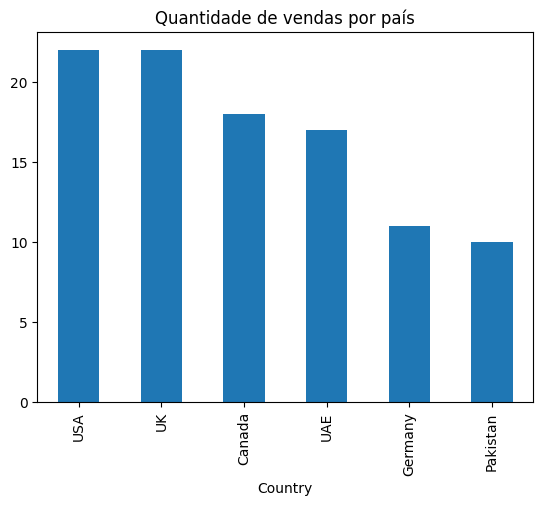

In [24]:
df['Country'].value_counts().plot(kind='bar')
plt.title('Quantidade de vendas por país')
plt.show()

Comentário

A análise revelou que os Estados Unidos e o Reino Unido apresentam o maior número de pedidos registrados. Isso sugere uma forte demanda por produtos Apple nesses mercados, possivelmente devido ao maior poder aquisitivo da população e à ampla popularização da marca. Já países com menor quantidade de vendas podem representar mercados menos explorados ou com menor capacidade de consumo de smartphones premium.

2-Quais modelos de iPhone são mais populares entre os consumidores?

Objetivo

Descobrir quais aparelhos apresentam maior aceitação no mercado.

In [25]:
df['iPhone_Model'].value_counts()

,count
iPhone_Model,
iPhone 14 Pro,24
iPhone 15 Pro Max,22
iPhone 15,16
iPhone 13,14
iPhone 12,13
iPhone 14,11


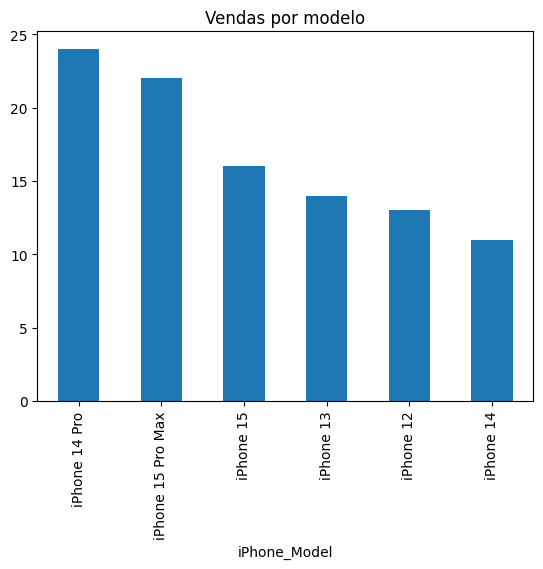

In [26]:
df['iPhone_Model'].value_counts().plot(kind='bar')
plt.title('Vendas por modelo')
plt.show()

Comentário

Os resultados mostram que os modelos mais recentes e avançados concentram a maior parte das vendas. Isso indica que muitos consumidores estão dispostos a investir em tecnologias mais modernas, mesmo quando os preços são mais elevados. A popularidade dos modelos da linha Pro demonstra que recursos avançados e maior desempenho são fatores importantes na decisão de compra.

3-Em qual país foi realizada a compra do iPhone mais caro e qual foi a forma de pagamento utilizada?

Objetivo

Analisar o contexto da venda de maior valor registrada no dataset.

In [27]:
df.loc[df['Price'].idxmax(), ['Country', 'Payment_Method', 'iPhone_Model', 'Price']]

,16
Country,Germany
Payment_Method,PayPal
iPhone_Model,iPhone 13
Price,1992


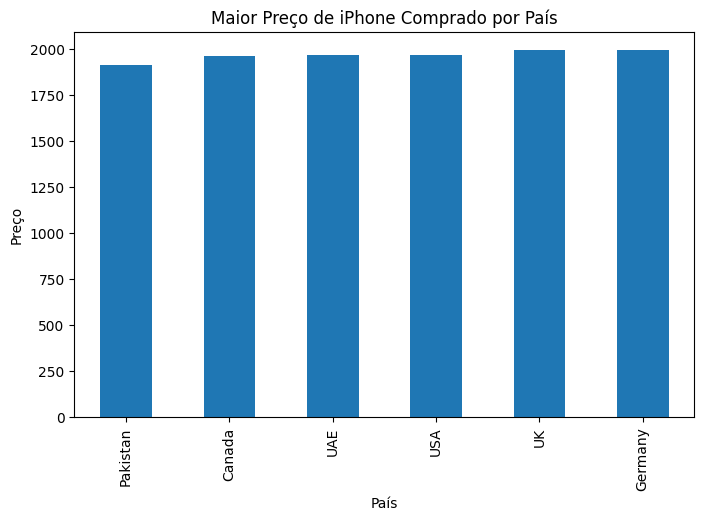

In [28]:
pais_vendas = df.groupby('Country')['Price'].max().sort_values()

plt.figure(figsize=(8,5))
pais_vendas.plot(kind='bar')

plt.title('Maior Preço de iPhone Comprado por País')
plt.xlabel('País')
plt.ylabel('Preço')

plt.show()

Comentário

Ao identificar o país e a forma de pagamento utilizados na compra do aparelho mais caro, é possível compreender melhor o perfil desse tipo de transação. Compras de alto valor podem estar associadas a mercados específicos ou a determinados métodos de pagamento que oferecem maior praticidade e segurança ao consumidor.

4-Qual é a forma de pagamento mais utilizada no país que realizou o maior número de compras?

Objetivo

Investigar o comportamento dos consumidores no mercado mais ativo do dataset.

In [29]:
pais_mais_vendas = df['Country'].value_counts().idxmax()

df[df['Country'] == pais_mais_vendas]['Payment_Method'].value_counts()

,count
Payment_Method,
Debit Card,10
Cash,5
Credit Card,4
PayPal,3


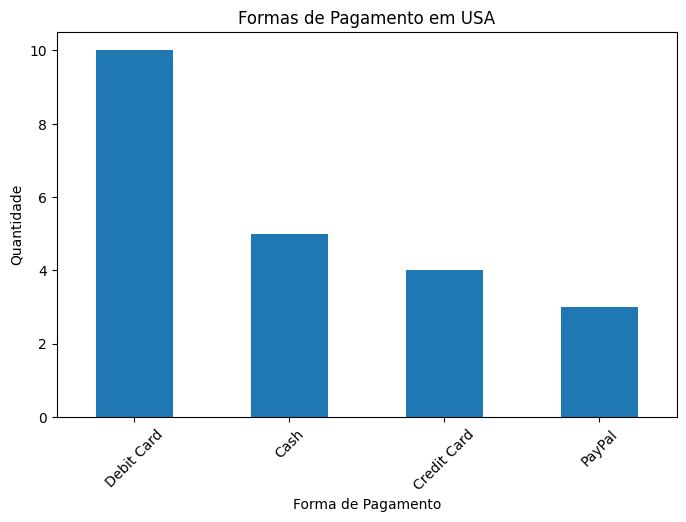

In [30]:
pais_mais_vendas = df['Country'].value_counts().idxmax()

pagamentos = (
    df[df['Country'] == pais_mais_vendas]
    ['Payment_Method']
    .value_counts()
)

plt.figure(figsize=(8,5))
pagamentos.plot(kind='bar')

plt.title(f'Formas de Pagamento em {pais_mais_vendas}')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.show()

Comentário

Essa análise ajuda a entender os hábitos de consumo do principal mercado identificado na base de dados. Conhecer o método de pagamento preferido dos clientes pode auxiliar empresas na definição de estratégias comerciais e na otimização dos meios de pagamento disponibilizados.

5-Qual capacidade de armazenamento é mais procurada pelos consumidores?
Objetivo

Entender as preferências dos clientes em relação às configurações dos aparelhos.

In [31]:
df['Storage'].value_counts()

,count
Storage,
256GB,38
128GB,34
512GB,28


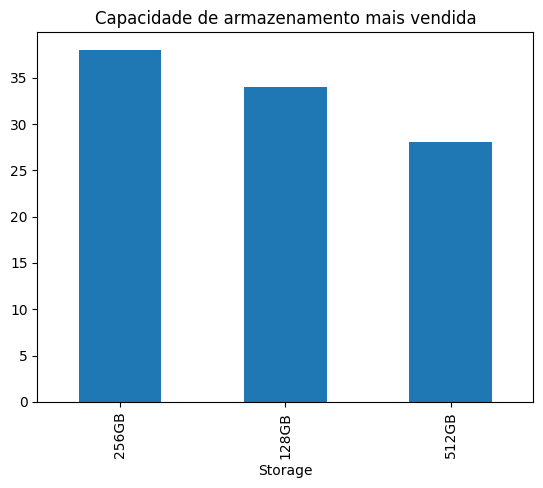

In [32]:
df['Storage'].value_counts().plot(kind='bar')
plt.title('Capacidade de armazenamento mais vendida')
plt.show()

Comentário

A preferência por determinadas capacidades de armazenamento revela o perfil dos consumidores. Capacidades maiores podem indicar usuários que utilizam intensivamente fotos, vídeos e aplicativos, enquanto capacidades menores costumam atrair consumidores que priorizam custo-benefício.

6-O método de pagamento influencia o faturamento obtido?
Objetivo

Verificar se determinados meios de pagamento estão associados a compras de maior valor.

In [33]:
df.groupby('Payment_Method')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Payment_Method,
Debit Card,199672
Credit Card,112331
Cash,98565
PayPal,83885


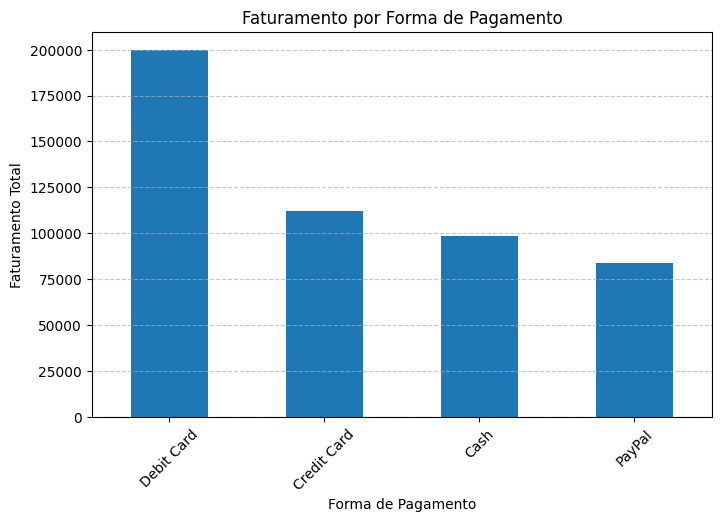

In [34]:

df['Revenue'] = df['Price'] * df['Quantity']


faturamento_pagamento = (
    df.groupby('Payment_Method')['Revenue']
    .sum()
    .sort_values(ascending=False)
)


plt.figure(figsize=(8,5))
faturamento_pagamento.plot(kind='bar')

plt.title('Faturamento por Forma de Pagamento')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Faturamento Total')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Observa-se que alguns métodos de pagamento geram receitas significativamente maiores que outros. Isso pode indicar que clientes que utilizam determinadas formas de pagamento tendem a realizar compras mais caras ou adquirir mais produtos em uma única transação.

7-Existe relação entre o preço do aparelho e a quantidade vendida?


Objetivo

Analisar se aparelhos mais caros apresentam menor volume de vendas.

In [35]:
df.groupby('iPhone_Model').agg({
    'Price':'mean',
    'Quantity':'sum'
})

,Price,Quantity
iPhone_Model,,
iPhone 12,1489.538462,42
iPhone 13,1501.214286,59
iPhone 14,1537.090909,36
iPhone 14 Pro,1525.500000,66
iPhone 15,1413.000000,57
iPhone 15 Pro Max,1380.272727,73


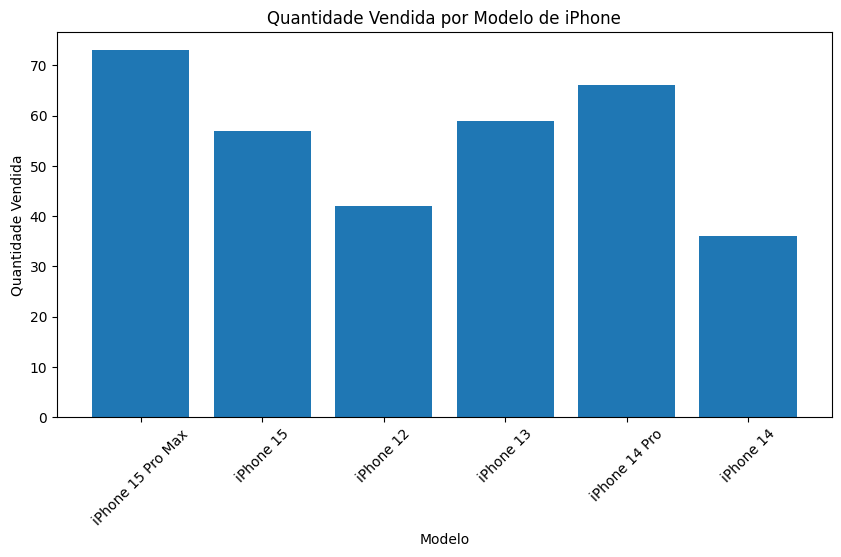

In [36]:
relacao = df.groupby('iPhone_Model').agg({
    'Price': 'mean',
    'Quantity': 'sum'
}).sort_values('Price')

plt.figure(figsize=(10,5))

plt.bar(relacao.index, relacao['Quantity'])

plt.title('Quantidade Vendida por Modelo de iPhone')
plt.xlabel('Modelo')
plt.ylabel('Quantidade Vendida')

plt.xticks(rotation=45)

plt.show()

Comentário

Essa análise permite verificar se o preço influencia diretamente a demanda. Caso modelos mais caros continuem apresentando vendas elevadas, isso pode indicar uma percepção de valor muito forte da marca Apple entre os consumidores.

8-Quais cores de iPhone são mais escolhidas pelos clientes?


Objetivo

Identificar quais cores possuem maior aceitação entre os consumidores e analisar possíveis tendências de preferência estética. Essa informação pode auxiliar fabricantes e varejistas no planejamento de estoque, na definição de estratégias de marketing e na previsão da demanda por determinadas versões dos aparelhos.

In [37]:

cores = df['Color'].value_counts()

cores


cores = df['Color'].value_counts()

percentual = round(
    (cores / cores.sum()) * 100,
    2
)

pd.DataFrame({
    'Quantidade': cores,
    'Percentual (%)': percentual
})

,Quantidade,Percentual (%)
Color,,
Blue,25,25.0
White,22,22.0
Purple,19,19.0
Red,19,19.0
Black,15,15.0


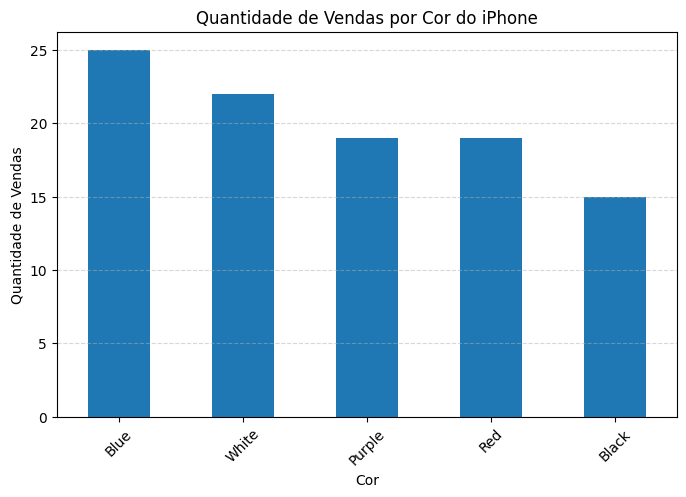

In [38]:
cores = df['Color'].value_counts()

plt.figure(figsize=(8,5))

cores.plot(
    kind='bar'
)

plt.title('Quantidade de Vendas por Cor do iPhone')
plt.xlabel('Cor')
plt.ylabel('Quantidade de Vendas')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Comentário

O gráfico permite identificar quais cores de iPhone são mais populares entre os consumidores. As cores com maior número de vendas demonstram uma preferência do mercado por determinados estilos e características visuais dos aparelhos. Essa tendência pode estar relacionada a fatores como moda, percepção de sofisticação, praticidade no uso diário ou até mesmo às opções de cores disponíveis nos modelos mais recentes.

Além disso, conhecer as preferências dos clientes é importante para o planejamento da produção e da distribuição dos produtos, permitindo que a empresa mantenha estoques compatíveis com a demanda de cada cor. Dessa forma, é possível reduzir custos com armazenamento de versões menos procuradas e aumentar a disponibilidade das opções mais desejadas pelos consumidores.

Conclusão

A análise exploratória do conjunto de dados de vendas de iPhones permitiu identificar padrões relevantes sobre o comportamento dos consumidores, os produtos mais procurados e os fatores que influenciam o faturamento das vendas.

Os resultados mostraram que alguns países concentram a maior parte das compras e do faturamento, evidenciando mercados mais estratégicos para a comercialização dos produtos. Também foi possível observar que determinados modelos de iPhone possuem maior popularidade, indicando uma preferência dos consumidores por aparelhos que oferecem um bom equilíbrio entre tecnologia, desempenho e preço.

A análise dos métodos de pagamento revelou diferenças no faturamento gerado por cada forma de pagamento, sugerindo que certos meios estão associados a compras de maior valor. Além disso, a investigação sobre o período das vendas permitiu identificar meses com maior volume de comercialização, o que pode indicar a influência de fatores sazonais, promoções ou lançamentos de novos modelos.

Outro aspecto importante observado foi a relação entre o preço dos aparelhos e a quantidade vendida. Os resultados indicam que, mesmo possuindo preços elevados, alguns modelos continuam apresentando boa demanda, demonstrando a força da marca Apple e a disposição dos consumidores em investir em dispositivos mais avançados.

Por fim, a análise das cores mais escolhidas mostrou que as preferências estéticas também influenciam as decisões de compra, fornecendo informações úteis para o planejamento de estoque e estratégias de mercado.

De maneira geral, o trabalho demonstrou como a análise exploratória de dados pode transformar dados brutos em informações valiosas para a tomada de decisões. Por meio das perguntas elaboradas, dos gráficos construídos e da interpretação dos resultados, foi possível obter uma compreensão mais ampla do comportamento das vendas e das preferências dos consumidores no mercado de iPhones.